In [ ]:
# 50,51,52,53,54,56,75,201,202,203,204,205,208,210,211,212,214,216,218,219,220,221,222,223,224,226

In [ ]:
drop_idx = [
    48,
    49,
    50,
    51,
    52,
    54,
    73,
    199,
    200,
    201,
    202,
    203,
    206,
    208,
    209,
    210,
    212,
    214,
    216,
    217,
    218,
    219,
    220,
    221,
    222,
    224,
]

df = df.drop(index=drop_idx)
df = df.reset_index(drop=True)

In [4]:
df.to_csv('../output/23&24_output.csv', index=False)

In [ ]:
import os

import pandas as pd

base_path = '../output'

# ✅ filtered 파일도 포함해서 slope_labels_*.csv 전부 읽기
target_files = sorted(
    [
        f
        for f in os.listdir(base_path)
        if f.startswith('slope_labels_') and f.endswith('.csv')
    ]
)

print('읽을 파일 목록:')
for f in target_files:
    print(' -', f)

all_data = []

for file in target_files:
    full_path = os.path.join(base_path, file)

    try:
        temp_df = pd.read_csv(full_path)
        temp_df['source_file'] = file  # 출처 추적용
        all_data.append(temp_df)
        print(f'성공: {full_path} 읽기 완료')
    except FileNotFoundError:
        print(f'실패: {full_path} 파일을 찾을 수 없습니다.')
    except Exception as e:
        print(f'실패: {full_path} 읽기 중 오류 발생 -> {e}')

if all_data:
    df = pd.concat(all_data, ignore_index=True)

    if 'slope_avg' in df.columns:
        df['slope_avg'] = pd.to_numeric(df['slope_avg'], errors='coerce')
        print('-' * 30)
        print(f'최종 합쳐진 데이터 행 개수: {len(df)}')
        print(df['slope_avg'].describe())
    else:
        print('경고: slope_avg 컬럼이 없습니다.')
        print(f'최종 합쳐진 데이터 행 개수: {len(df)}')
        print('컬럼 목록:', df.columns.tolist())

    save_path = os.path.join(base_path, 'merged_slope_labels.csv')
    df.to_csv(save_path, index=False, encoding='utf-8-sig')
    print(f'저장 완료: {save_path}')
else:
    print('읽어온 데이터가 없습니다.')

읽을 파일 목록:
 - slope_labels_002.csv
 - slope_labels_003.csv
 - slope_labels_004.csv
 - slope_labels_005.csv
 - slope_labels_006.csv
 - slope_labels_007.csv
 - slope_labels_008.csv
 - slope_labels_009.csv
 - slope_labels_010.csv
 - slope_labels_011_015.csv
 - slope_labels_021.csv
 - slope_labels_022.csv
 - slope_labels_23_24.csv
 - slope_labels_filtered_017.csv
 - slope_labels_filtered_018.csv
 - slope_labels_filtered_019.csv
 - slope_labels_filtered_020.csv
성공: ../output\slope_labels_002.csv 읽기 완료
성공: ../output\slope_labels_003.csv 읽기 완료
성공: ../output\slope_labels_004.csv 읽기 완료
성공: ../output\slope_labels_005.csv 읽기 완료
성공: ../output\slope_labels_006.csv 읽기 완료
성공: ../output\slope_labels_007.csv 읽기 완료
성공: ../output\slope_labels_008.csv 읽기 완료
성공: ../output\slope_labels_009.csv 읽기 완료
성공: ../output\slope_labels_010.csv 읽기 완료
성공: ../output\slope_labels_011_015.csv 읽기 완료
성공: ../output\slope_labels_021.csv 읽기 완료
성공: ../output\slope_labels_022.csv 읽기 완료
성공: ../output\slope_labels_23_24.csv 읽기 완료
성

In [ ]:
import os

import pandas as pd

base_path = '../output'

target_files = sorted(
    [
        f
        for f in os.listdir(base_path)
        if f.startswith('slope_labels_') and f.endswith('.csv')
    ]
)

print('읽을 파일 목록:')
for f in target_files:
    print(' -', f)

all_data = []

for file in target_files:
    full_path = os.path.join(base_path, file)

    try:
        temp_df = pd.read_csv(full_path)
        temp_df['source_file'] = file
        all_data.append(temp_df)
        print(f'성공: {full_path} 읽기 완료')
    except FileNotFoundError:
        print(f'실패: {full_path} 파일을 찾을 수 없습니다.')
    except Exception as e:
        print(f'실패: {full_path} 읽기 중 오류 발생 -> {e}')

if all_data:
    df = pd.concat(all_data, ignore_index=True)

    # ✅ 삭제할 열 제거
    drop_cols = ['Unnamed: 0.1', 'Unnamed: 0', 'slope_origin', 'source_file']
    df = df.drop(columns=drop_cols, errors='ignore')

    # ✅ slope_avg 숫자형 변환
    if 'slope_avg' in df.columns:
        df['slope_avg'] = pd.to_numeric(df['slope_avg'], errors='coerce')

    print('-' * 30)
    print(f'최종 합쳐진 데이터 행 개수: {len(df)}')
    print('최종 컬럼:', df.columns.tolist())

    if 'slope_avg' in df.columns:
        print(df['slope_avg'].describe())

    save_path = os.path.join(base_path, 'merged_slope_labels_clean.csv')
    df.to_csv(save_path, index=False, encoding='utf-8-sig')
    print(f'저장 완료: {save_path}')
else:
    print('읽어온 데이터가 없습니다.')

읽을 파일 목록:
 - slope_labels_002.csv
 - slope_labels_003.csv
 - slope_labels_004.csv
 - slope_labels_005.csv
 - slope_labels_006.csv
 - slope_labels_007.csv
 - slope_labels_008.csv
 - slope_labels_009.csv
 - slope_labels_010.csv
 - slope_labels_011_015.csv
 - slope_labels_021.csv
 - slope_labels_022.csv
 - slope_labels_23_24.csv
 - slope_labels_filtered_017.csv
 - slope_labels_filtered_018.csv
 - slope_labels_filtered_019.csv
 - slope_labels_filtered_020.csv
성공: ../output\slope_labels_002.csv 읽기 완료
성공: ../output\slope_labels_003.csv 읽기 완료
성공: ../output\slope_labels_004.csv 읽기 완료
성공: ../output\slope_labels_005.csv 읽기 완료
성공: ../output\slope_labels_006.csv 읽기 완료
성공: ../output\slope_labels_007.csv 읽기 완료
성공: ../output\slope_labels_008.csv 읽기 완료
성공: ../output\slope_labels_009.csv 읽기 완료
성공: ../output\slope_labels_010.csv 읽기 완료
성공: ../output\slope_labels_011_015.csv 읽기 완료
성공: ../output\slope_labels_021.csv 읽기 완료
성공: ../output\slope_labels_022.csv 읽기 완료
성공: ../output\slope_labels_23_24.csv 읽기 완료
성

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13933 entries, 0 to 13932
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   folder     13933 non-null  str    
 1   prefix     13933 non-null  str    
 2   path       13933 non-null  str    
 3   slope_avg  13932 non-null  float64
dtypes: float64(1), str(3)
memory usage: 435.5 KB


In [4]:
df = df[df['slope_avg'] < 17]

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 13912 entries, 0 to 13932
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   folder     13912 non-null  str    
 1   prefix     13912 non-null  str    
 2   path       13912 non-null  str    
 3   slope_avg  13912 non-null  float64
dtypes: float64(1), str(3)
memory usage: 543.4 KB


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13912 entries, 0 to 13911
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   folder     13912 non-null  str    
 1   prefix     13912 non-null  str    
 2   path       13912 non-null  str    
 3   slope_avg  13912 non-null  float64
dtypes: float64(1), str(3)
memory usage: 434.9 KB


c:\potenup3\deeplearning\wheel-safe\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


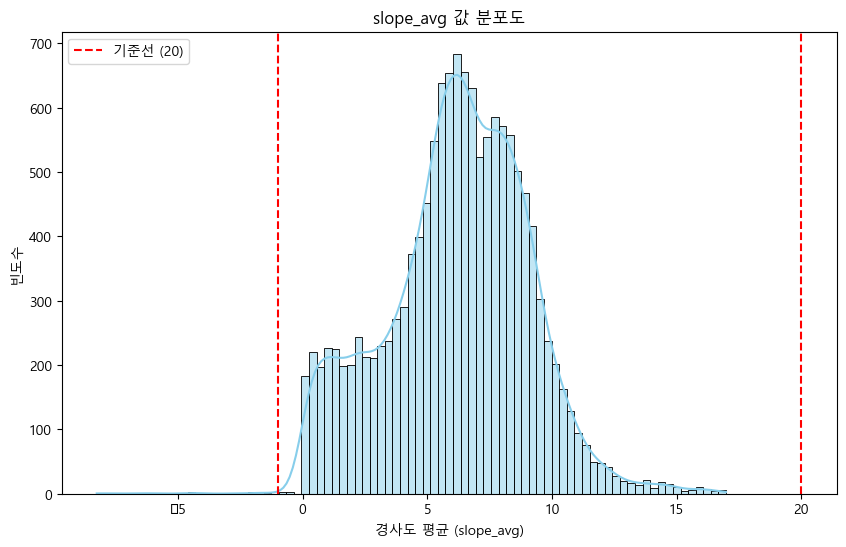

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정 (필요 시)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 데이터 시각화
plt.figure(figsize=(10, 6))
sns.histplot(df['slope_avg'].dropna(), kde=True, color='skyblue')

# 절댓값 20 지점에 가이드라인 표시
plt.axvline(20, color='red', linestyle='--', label='기준선 (20)')
plt.axvline(-1, color='red', linestyle='--')

plt.title('slope_avg 값 분포도')
plt.xlabel('경사도 평균 (slope_avg)')
plt.ylabel('빈도수')
plt.legend()
plt.show()

In [48]:
flat_mask = (df['slope_avg'] >= 0) & (df['slope_avg'] < 4.1)

df_flat = df[flat_mask].copy()
df_other = df[~flat_mask].copy()

df_flat_extra = df_flat.sample(frac=1.0, replace=True, random_state=42)

df_up = pd.concat([df_other, df_flat, df_flat_extra], ignore_index=True)

c:\potenup3\deeplearning\wheel-safe\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


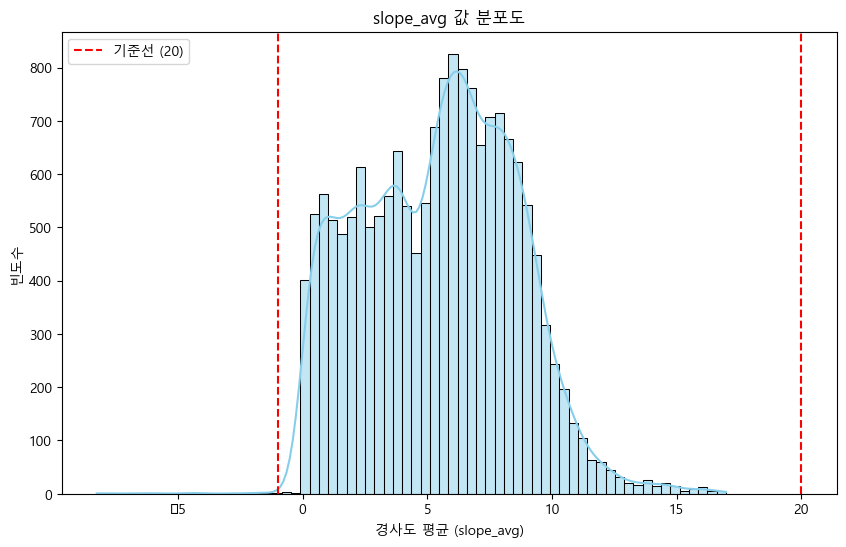

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정 (필요 시)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 데이터 시각화
plt.figure(figsize=(10, 6))
sns.histplot(df_up['slope_avg'].dropna(), kde=True, color='skyblue')

# 절댓값 20 지점에 가이드라인 표시
plt.axvline(20, color='red', linestyle='--', label='기준선 (20)')
plt.axvline(-1, color='red', linestyle='--')

plt.title('slope_avg 값 분포도')
plt.xlabel('경사도 평균 (slope_avg)')
plt.ylabel('빈도수')
plt.legend()
plt.show()

In [50]:
df_up.info()

<class 'pandas.DataFrame'>
RangeIndex: 16957 entries, 0 to 16956
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   folder     16957 non-null  str    
 1   prefix     16957 non-null  str    
 2   path       16957 non-null  str    
 3   slope_avg  16957 non-null  float64
dtypes: float64(1), str(3)
memory usage: 530.0 KB


In [51]:
df_up.to_csv('../output/slope_labels_up_total_0310.csv', index=False)

C:\Users\user\AppData\Local\Temp\ipykernel_20780\3698820412.py:19: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\potenup3\deeplearning\wheel-safe\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


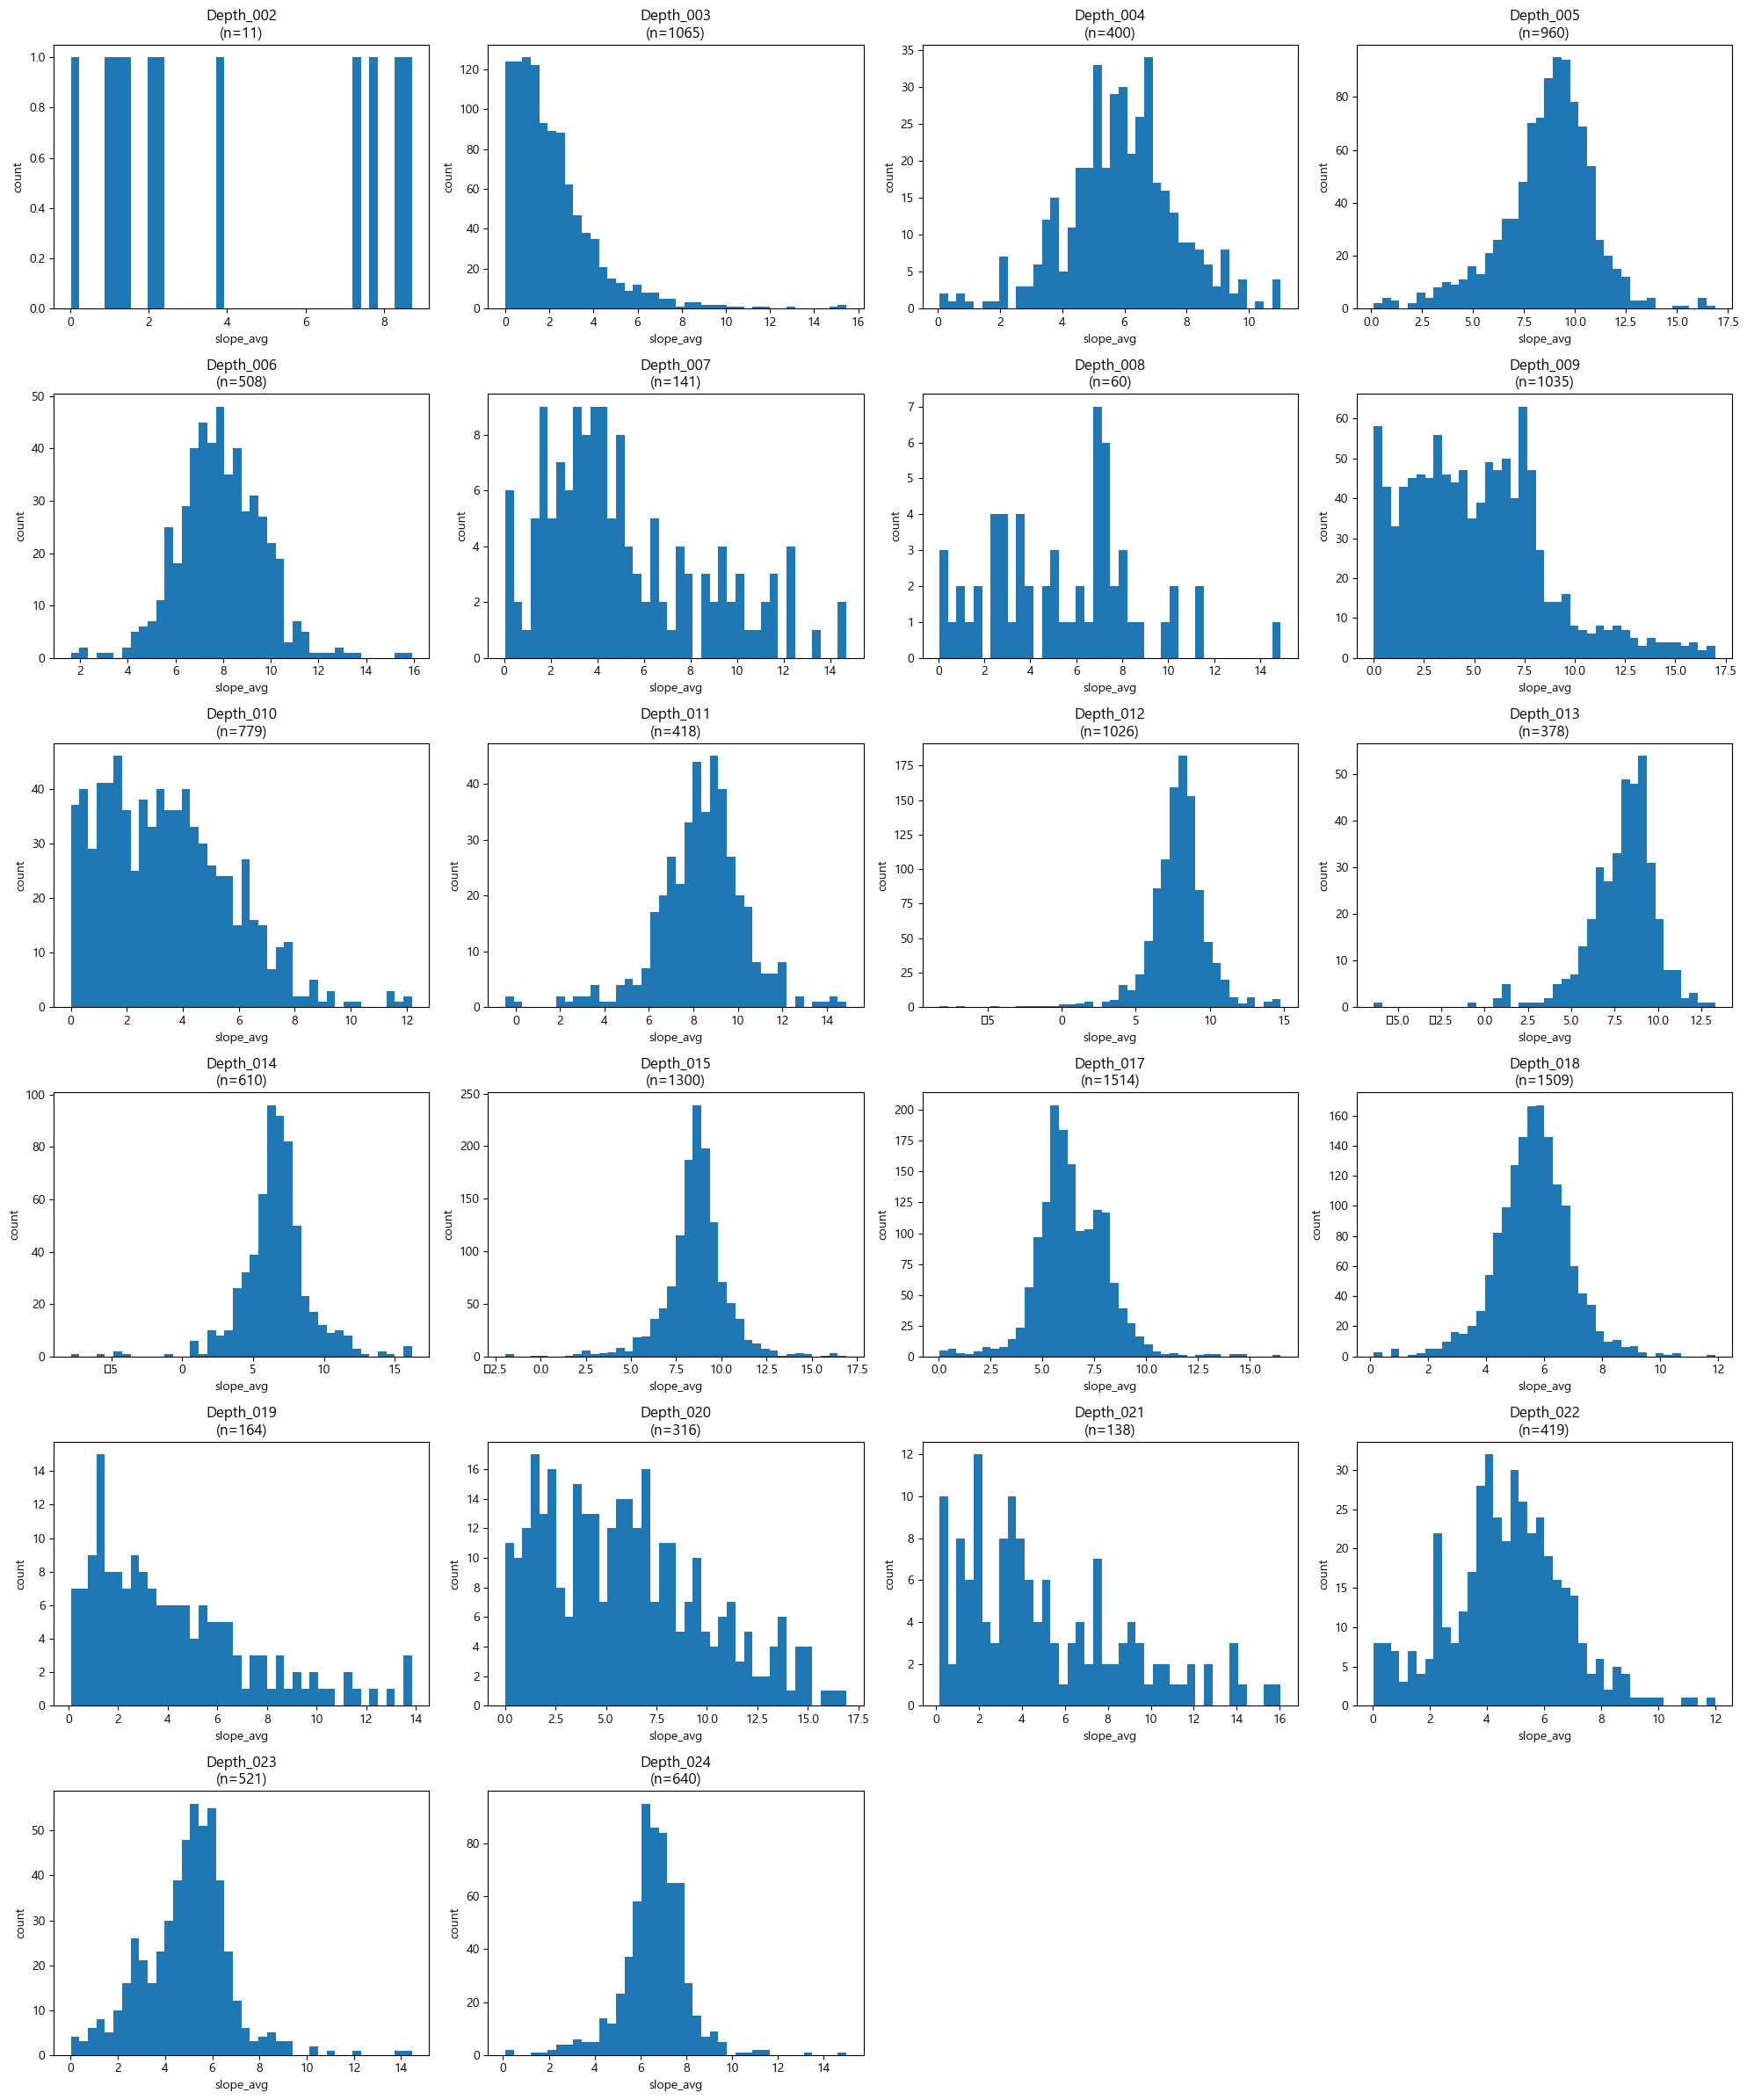

In [52]:
import matplotlib.pyplot as plt

folders = sorted(df['folder'].dropna().unique())

n_cols = 4
n_rows = (len(folders) + n_cols - 1) // n_cols

plt.figure(figsize=(20, n_rows * 4))

for i, folder in enumerate(folders, 1):
    temp = df.loc[df['folder'] == folder, 'slope_avg'].dropna()

    plt.subplot(n_rows, n_cols, i)
    plt.hist(temp, bins=40)
    plt.title(f'{folder}\n(n={len(temp)})')
    plt.xlabel('slope_avg')
    plt.ylabel('count')

plt.tight_layout()
plt.show()

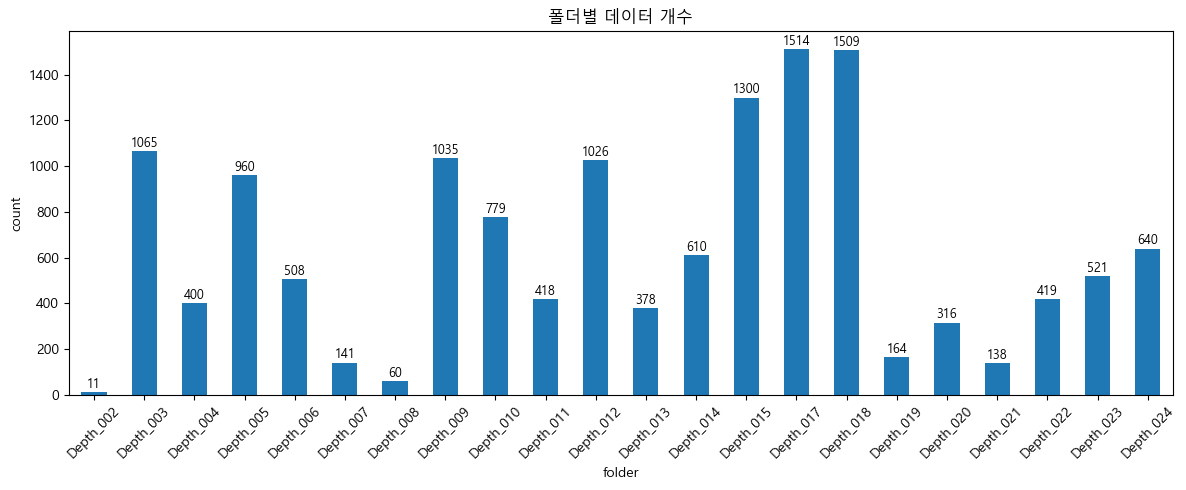

In [41]:
import matplotlib.pyplot as plt

folder_counts = df['folder'].value_counts().sort_index()

ax = folder_counts.plot(kind='bar', figsize=(12, 5))

plt.title('폴더별 데이터 개수')
plt.xlabel('folder')
plt.ylabel('count')
plt.xticks(rotation=45)

# 막대 위에 개수 표시
for i, v in enumerate(folder_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [53]:
df_up.info()

<class 'pandas.DataFrame'>
RangeIndex: 16957 entries, 0 to 16956
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   folder     16957 non-null  str    
 1   prefix     16957 non-null  str    
 2   path       16957 non-null  str    
 3   slope_avg  16957 non-null  float64
dtypes: float64(1), str(3)
memory usage: 530.0 KB


In [56]:
import pandas as pd

# 새 파일 기준 test folder (30%)
test_folders = [
    'Depth_002',
    'Depth_005',
    'Depth_007',
    'Depth_010',
    'Depth_011',
    'Depth_017',
    'Depth_022',
]

# split
train_df = df_up[~df_up['folder'].isin(test_folders)].copy()
test_df = df_up[df_up['folder'].isin(test_folders)].copy()

# 확인
print('전체 개수 :', len(df_up))
print('train 개수:', len(train_df))
print('test 개수 :', len(test_df))
print('train 비율:', len(train_df) / len(df_up))
print('test 비율 :', len(test_df) / len(df_up))

print('\n[TEST folders]')
print(sorted(test_folders))

print('\n[TRAIN folders]')
print(sorted(train_df['folder'].dropna().unique()))

# 저장
train_df.to_csv('../output/slope_labels_up_total_train_70%.csv', index=False)
test_df.to_csv('../output/slope_labels_up_total_test_30%.csv', index=False)

print('\n저장 완료')

전체 개수 : 16957
train 개수: 11869
test 개수 : 5088
train 비율: 0.6999469245739223
test 비율 : 0.30005307542607773

[TEST folders]
['Depth_002', 'Depth_005', 'Depth_007', 'Depth_010', 'Depth_011', 'Depth_017', 'Depth_022']

[TRAIN folders]
['Depth_003', 'Depth_004', 'Depth_006', 'Depth_008', 'Depth_009', 'Depth_012', 'Depth_013', 'Depth_014', 'Depth_015', 'Depth_018', 'Depth_019', 'Depth_020', 'Depth_021', 'Depth_023', 'Depth_024']

저장 완료


In [1]:
import pandas as pd

df = pd.read_csv(
    'C:\potenup3\deeplearning\wheel-safe\output\slope_labels_total_0310.csv'
)
df.head()

,folder,prefix,path,slope_avg
0,Depth_002,ZED1_KSC_001251,c:\Workspaces\projects\wheel-safe\data\raw\Dep...,1.03
1,Depth_002,ZED1_KSC_001533,c:\Workspaces\projects\wheel-safe\data\raw\Dep...,7.76
2,Depth_002,ZED1_KSC_001646,c:\Workspaces\projects\wheel-safe\data\raw\Dep...,2.19
3,Depth_002,ZED1_KSC_001835,c:\Workspaces\projects\wheel-safe\data\raw\Dep...,3.91
4,Depth_002,ZED1_KSC_001849,c:\Workspaces\projects\wheel-safe\data\raw\Dep...,0.01


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13912 entries, 0 to 13911
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   folder     13912 non-null  str    
 1   prefix     13912 non-null  str    
 2   path       13912 non-null  str    
 3   slope_avg  13912 non-null  float64
dtypes: float64(1), str(3)
memory usage: 434.9 KB


In [3]:
df['slope_avg'] = df['slope_avg'].abs()

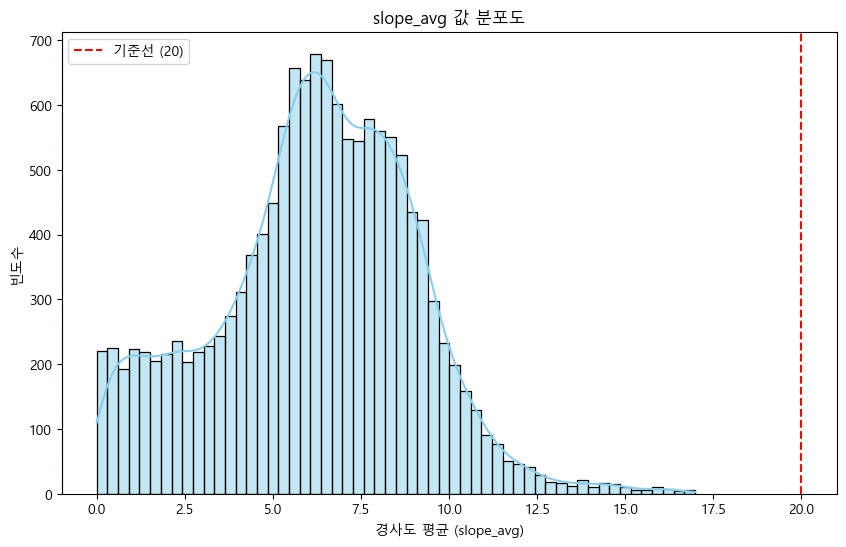

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정 (필요 시)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 데이터 시각화
plt.figure(figsize=(10, 6))
sns.histplot(df['slope_avg'].dropna(), kde=True, color='skyblue')

# 절댓값 20 지점에 가이드라인 표시
plt.axvline(20, color='red', linestyle='--', label='기준선 (20)')
plt.axvline(-1, color='red', linestyle='--')

plt.title('slope_avg 값 분포도')
plt.xlabel('경사도 평균 (slope_avg)')
plt.ylabel('빈도수')
plt.legend()
plt.show()

In [5]:
test_folders = [
    'Depth_004',
    'Depth_007',
    'Depth_010',
    'Depth_012',
    'Depth_013',
    'Depth_014',
    'Depth_020',
    'Depth_023',
]

train_df = df[~df['folder'].isin(test_folders)].copy()
test_df = df[df['folder'].isin(test_folders)].copy()

print('전체 개수 :', len(df))
print('train 개수:', len(train_df))
print('test 개수 :', len(test_df))
print('train 비율:', len(train_df) / len(df))
print('test 비율 :', len(test_df) / len(df))

전체 개수 : 13912
train 개수: 9741
test 개수 : 4171
train 비율: 0.7001868890166763
test 비율 : 0.29981311098332375


In [6]:
# 저장
train_df.to_csv('../output/slope_labels_total_train_70%.csv', index=False)
test_df.to_csv('../output/slope_labels_total_test_30%.csv', index=False)

print('\n저장 완료')


저장 완료


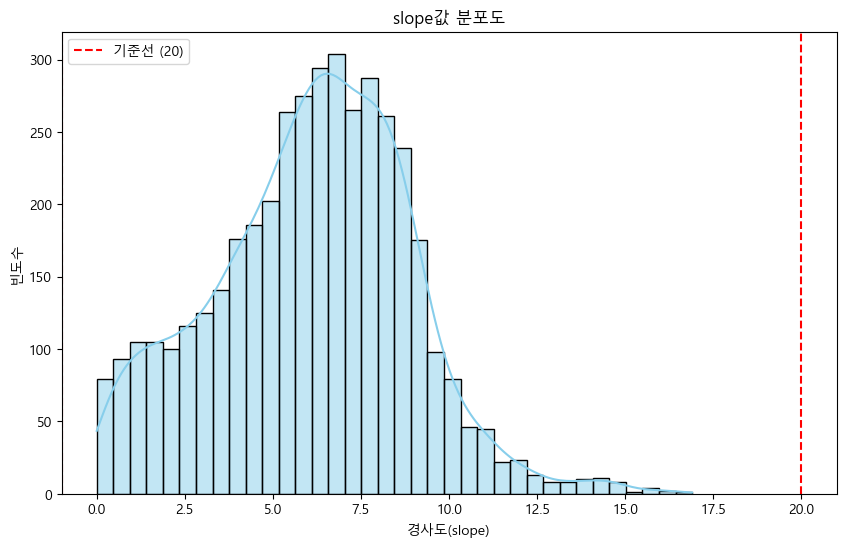

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정 (필요 시)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 데이터 시각화
plt.figure(figsize=(10, 6))
sns.histplot(test_df['slope_avg'].dropna(), kde=True, color='skyblue')

# 절댓값 20 지점에 가이드라인 표시
plt.axvline(20, color='red', linestyle='--', label='기준선 (20)')
plt.axvline(-1, color='red', linestyle='--')

plt.title('slope값 분포도')
plt.xlabel('경사도(slope)')
plt.ylabel('빈도수')
plt.legend()
plt.show()

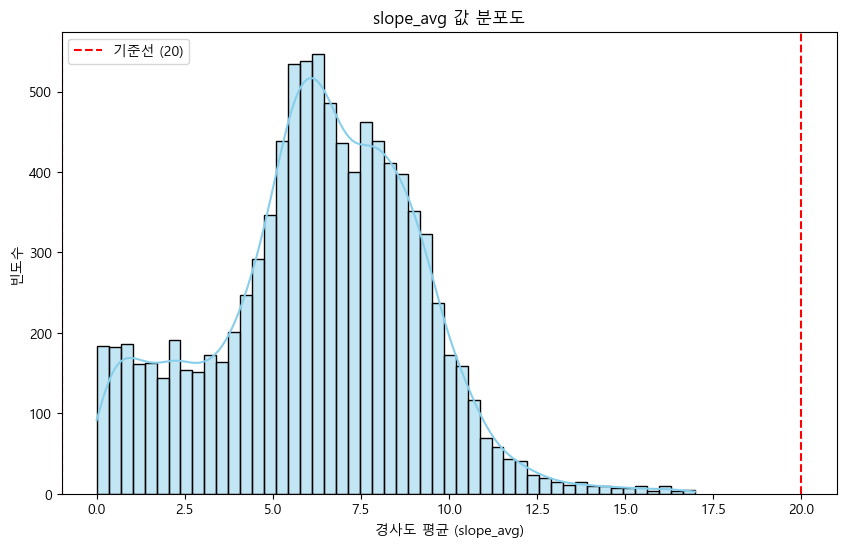

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정 (필요 시)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 데이터 시각화
plt.figure(figsize=(10, 6))
sns.histplot(train_df['slope_avg'].dropna(), kde=True, color='skyblue')

# 절댓값 20 지점에 가이드라인 표시
plt.axvline(20, color='red', linestyle='--', label='기준선 (20)')
plt.axvline(-1, color='red', linestyle='--')

plt.title('slope 값 분포도')
plt.xlabel('경사도(slope)')
plt.ylabel('빈도수')
plt.legend()
plt.show()

In [21]:
flat_mask = (train_df['slope_avg'] >= 0) & (train_df['slope_avg'] < 4.1)

train_flat = train_df[flat_mask].copy()
train_other = train_df[~flat_mask].copy()

train_flat_extra = train_flat.sample(frac=0.5, replace=True, random_state=42)

train_df_up = pd.concat([train_other, train_flat, train_flat_extra], ignore_index=True)

print('원본 train 개수:', len(train_df))
print('오버샘플 후 train 개수:', len(train_df_up))
print(
    '0~4.1 원본 개수:',
    ((train_df['slope_avg'] >= 0) & (train_df['slope_avg'] < 4.1)).sum(),
)
print(
    '0~4.1 오버샘플 후 개수:',
    ((train_df_up['slope_avg'] >= 0) & (train_df_up['slope_avg'] < 4.1)).sum(),
)

원본 train 개수: 9741
오버샘플 후 train 개수: 10776
0~4.1 원본 개수: 2070
0~4.1 오버샘플 후 개수: 3105


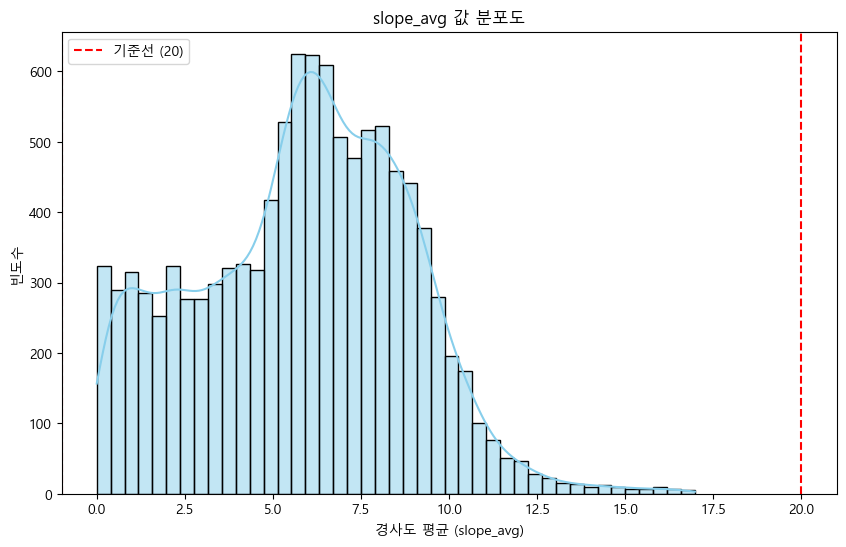

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정 (필요 시)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 데이터 시각화
plt.figure(figsize=(10, 6))
sns.histplot(train_df_up['slope_avg'].dropna(), kde=True, color='skyblue')

# 절댓값 20 지점에 가이드라인 표시
plt.axvline(20, color='red', linestyle='--', label='기준선 (20)')
plt.axvline(-1, color='red', linestyle='--')

plt.title('slope값 분포도')
plt.xlabel('경사도(slope)')
plt.ylabel('빈도수')
plt.legend()
plt.show()

In [24]:
train_df_up.to_csv('../output/slope_labels_total_up_to_train_70%.csv', index=False)